In [1]:
import xml.etree.ElementTree as ET
xml_file = "A지역/050301576020_01_pan, mul(8Band), 30cm/050301576020_01_P001_PAN/24OCT31022252-P2AS-050301576020_01_P001.XML"
tree = ET.parse(xml_file)
root = tree.getroot()

# 방사보정 계수 추출
bands_info = {}
for band in root.findall(".//IMD/*"):  
    if band.tag.startswith("BAND_"):  
        band_name = band.tag
        abs_cal_factor = band.find("ABSCALFACTOR")
        eff_bandwidth = band.find("EFFECTIVEBANDWIDTH")

        if abs_cal_factor is not None and eff_bandwidth is not None:
            bands_info[band_name] = {
                "ABSCALFACTOR": float(abs_cal_factor.text),
                "EFFECTIVEBANDWIDTH": float(eff_bandwidth.text),
            }

print("📌 방사보정 계수:", bands_info)

# 태양 고도각(SUNEL) 추출
sun_el = root.find(".//MEANSUNEL")
sun_elevation = float(sun_el.text)
print('📌 태양 고도각:', sun_elevation)

# 지도 투영법 확인
map_projection = root.find(".//MAPPROJNAME")
zone = root.find(".//MAPZONE")
hemisphere = root.find(".//MAPHEMI")

if map_projection is not None:
    map_projection = map_projection.text
else:
    map_projection = "Unknown"

if zone is not None:
    zone = zone.text

else:
    zone = 'Unknown'

if hemisphere is not None:
    hemisphere_text = "North" if hemisphere.text == "N" else "South"
    epsg_code = f"EPSG:326{zone}" if hemisphere.text == "N" else f"EPSG:327{zone}"
else:
    hemisphere_text = "Unknown"
    epsg_code = "Unknown"

print(f"📌 지도 투영법: {map_projection}, Zone: {zone}, Hemisphere: {hemisphere_text}, EPSG: {epsg_code}")


# GSD 및 해상도 확인
product_gsd = root.find(".//PRODUCTGSD")
col_spacing = root.find(".//COLSPACING")
row_spacing = root.find(".//ROWSPACING")

if product_gsd is not None:
    product_gsd = float(product_gsd.text)
else:
    product_gsd = "Unknown"

if col_spacing is not None and row_spacing is not None:
    col_spacing = float(col_spacing.text)
    row_spacing = float(row_spacing.text)
else:
    col_spacing, row_spacing = "Unknown", "Unknown"

print(f"📌 GSD (m/pixel): {product_gsd}, Column Spacing: {col_spacing}, Row Spacing: {row_spacing}")

📌 방사보정 계수: {'BAND_P': {'ABSCALFACTOR': 0.006305575, 'EFFECTIVEBANDWIDTH': 0.35}}
📌 태양 고도각: 38.9
📌 지도 투영법: UTM, Zone: 52, Hemisphere: North, EPSG: EPSG:32652
📌 GSD (m/pixel): 0.3, Column Spacing: 0.3, Row Spacing: 0.3


## TIF 파일 분석

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [3]:
bands_info.keys()

dict_keys(['BAND_C', 'BAND_B', 'BAND_G', 'BAND_Y', 'BAND_R', 'BAND_RE1', 'BAND_RE2', 'BAND_N'])

📌 이미지 크기: 4148 x 4384
📌 밴드 개수: 8
📌 CRS(좌표계) : EPSG:32652
📌 변환 행렬 (Affine): | 1.20, 0.00, 314084.40|
| 0.00,-1.20, 3930807.60|
| 0.00, 0.00, 1.00|
BAND_C INFO
📌 최소값: 0, 최대값: 16383, 평균값: 450.616362801702


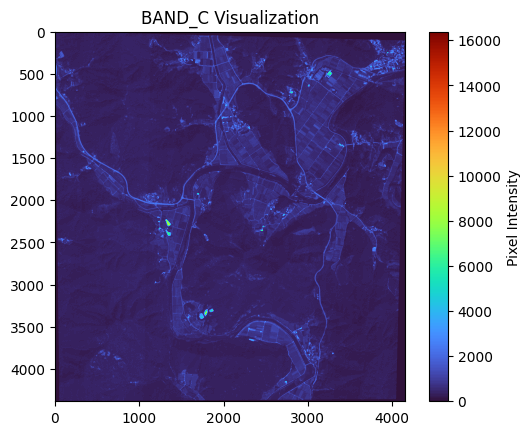

BAND_B INFO
📌 최소값: 0, 최대값: 16306, 평균값: 452.57798053894584


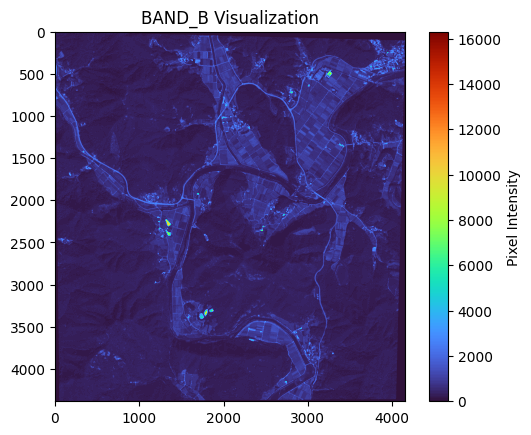

BAND_G INFO
📌 최소값: 0, 최대값: 16306, 평균값: 788.0491773033702


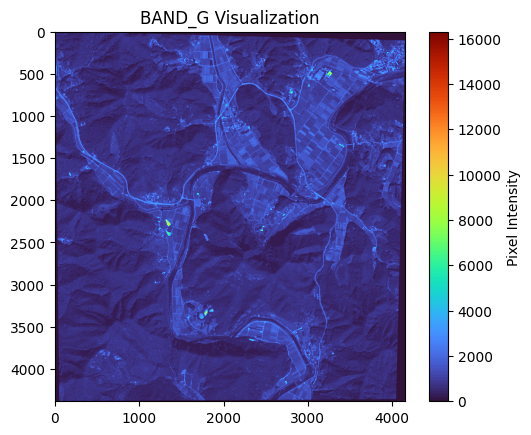

BAND_Y INFO
📌 최소값: 0, 최대값: 16329, 평균값: 821.684942428943


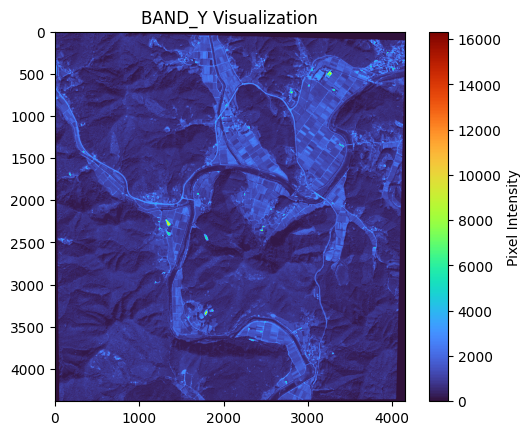

BAND_R INFO
📌 최소값: 0, 최대값: 16306, 평균값: 811.7298711915513


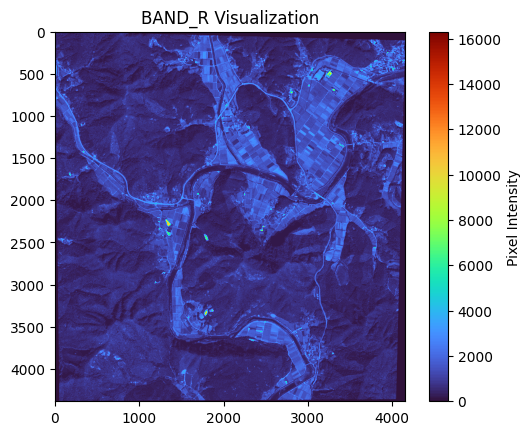

BAND_RE1 INFO
📌 최소값: 0, 최대값: 16380, 평균값: 1501.0223795853599


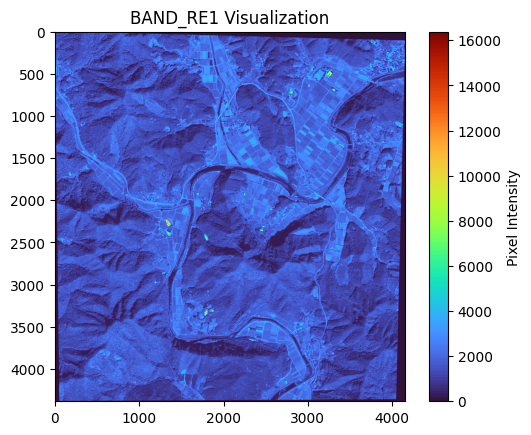

BAND_RE2 INFO
📌 최소값: 0, 최대값: 16381, 평균값: 2942.113381085951


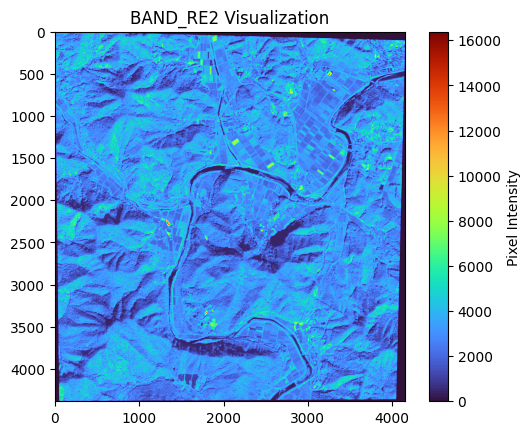

BAND_N INFO
📌 최소값: 0, 최대값: 14847, 평균값: 3631.1040738787137


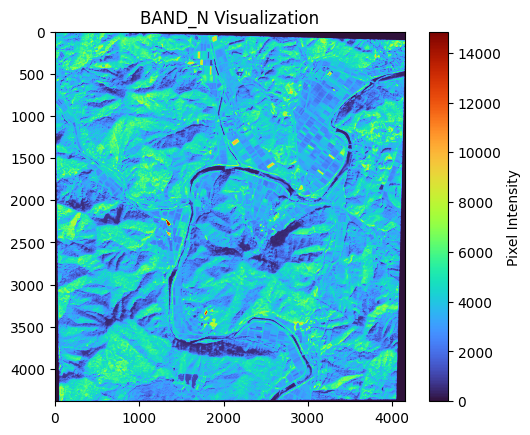

In [4]:
# GeoTIFF 파일경로
tif_file = "A지역/050301576020_01_pan, mul(8Band), 30cm/050301576020_01_P001_MUL/24OCT31022252-M2AS-050301576020_01_P001.TIF"

band_lst = bands_info.keys()

# 위성 이미지 읽기
with rasterio.open(tif_file) as src:
    
    meta = src.meta.copy()
    print(f"📌 이미지 크기: {src.width} x {src.height}")
    print(f"📌 밴드 개수: {src.count}")
    print(f"📌 CRS(좌표계) : {src.crs}")
    print(f"📌 변환 행렬 (Affine): {src.transform}")
    
    
    #밴드명과 TIF 파일 밴드 매칭
    num_bands = src.count
    if len(band_lst) != num_bands:
        print('밴드 숫자가 일치하지 않습니다.')
    
    bands_data = {}
    for i, _band_name in enumerate(band_lst):
        bands_data[_band_name] = src.read(i+1)
        
        print(f"{_band_name} INFO")
        # 기본 통계 정보 출력
        print(f"📌 최소값: {bands_data[_band_name].min()}, 최대값: {bands_data[_band_name].max()}, 평균값: {bands_data[_band_name].mean()}")
    
    
        # 이미지 시각화
        plt.imshow(bands_data[_band_name], cmap="turbo")
        plt.colorbar(label="Pixel Intensity")
        plt.title(f"{_band_name} Visualization")
        plt.show()

In [7]:
## 대기 보정 및 방사 보정 적용 함수
def apply_radiometric_correction(dn_array, abscal_factor, sun_elevation):
    # 태양 천청각 보정 (90도 - 태양 고도각)
    theta = np.deg2rad(90 - sun_elevation)
    cos_theta = np.cos(theta)
    
    ## 반사율 변환 공식
    reflectance = (dn_array * abscal_factor) / cos_theta
    
    return reflectance

In [8]:
for _band_name in band_lst:
    _dn_array = bands_data[_band_name]
    _abs_cal_factor = bands_info[_band_name]['ABSCALFACTOR']
    
    reflectance = apply_radiometric_correction(_dn_array, _abs_cal_factor, sun_elevation)
    bands_info[_band_name]['REFLECTANCE'] = reflectance
    

BAND_C REFLECTANCE_INFO
📌 최소값: 0.0, 최대값: 37.81431888029956, 평균값: 1.0400873366089436


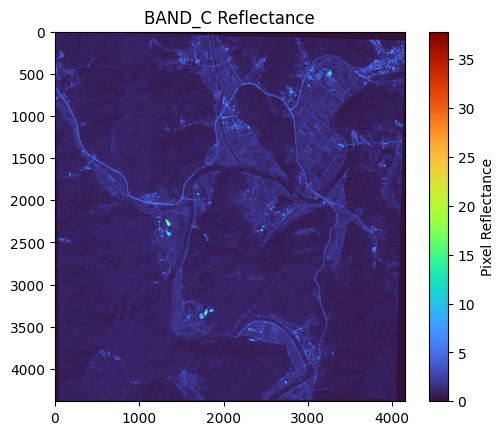

BAND_B REFLECTANCE_INFO
📌 최소값: 0.0, 최대값: 28.036648540926414, 평균값: 0.7781656922441237


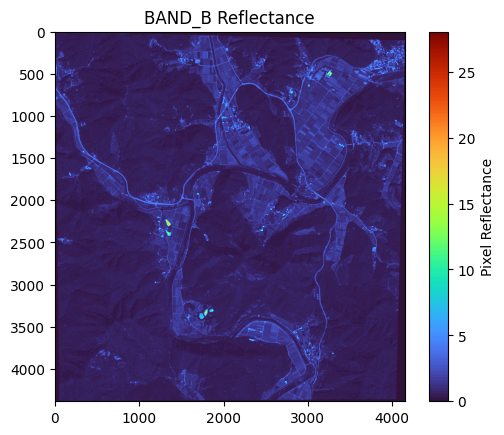

BAND_G REFLECTANCE_INFO
📌 최소값: 0.0, 최대값: 31.658091822180555, 평균값: 1.5299971308391953


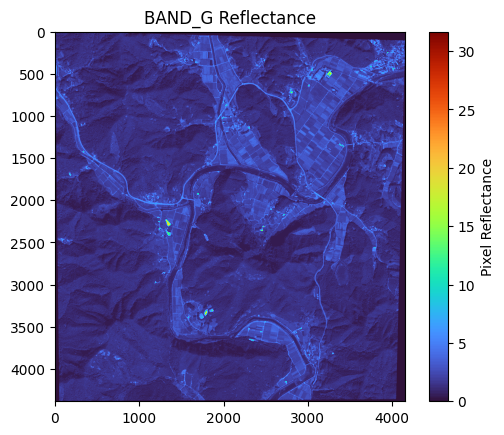

BAND_Y REFLECTANCE_INFO
📌 최소값: 0.0, 최대값: 17.479857676006038, 평균값: 0.8795967816874964


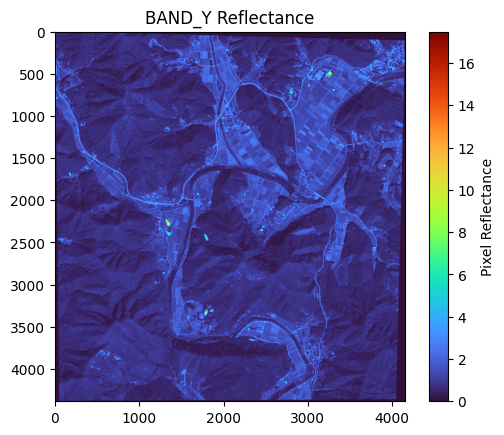

BAND_R REFLECTANCE_INFO
📌 최소값: 0.0, 최대값: 24.8970888891532, 평균값: 1.2394033335604646


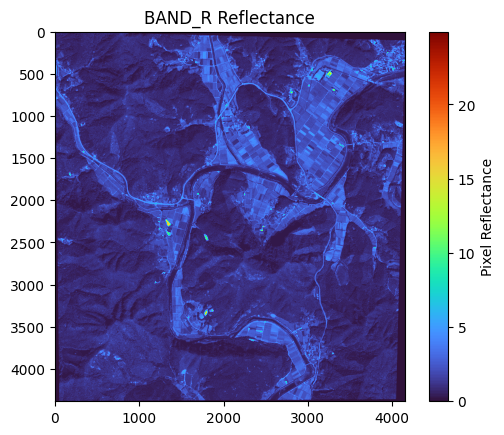

BAND_RE1 REFLECTANCE_INFO
📌 최소값: 0.0, 최대값: 8.757414438654596, 평균값: 0.8025076349038162


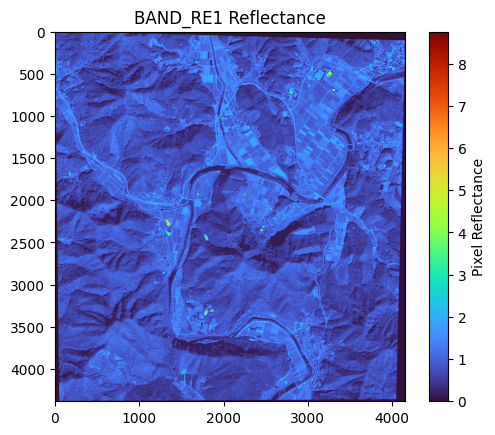

BAND_RE2 REFLECTANCE_INFO
📌 최소값: 0.0, 최대값: 8.289990982888337, 평균값: 1.4889257920662757


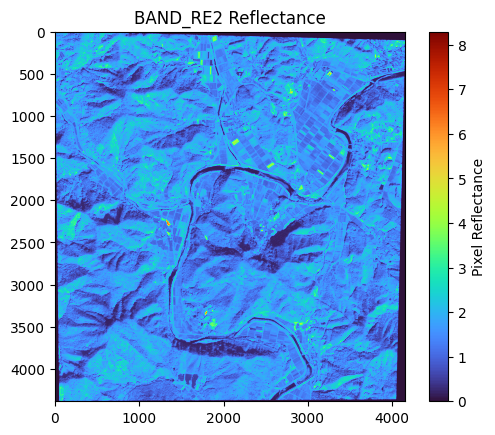

BAND_N REFLECTANCE_INFO
📌 최소값: 0.0, 최대값: 29.00534439268094, 평균값: 7.0937848850622345


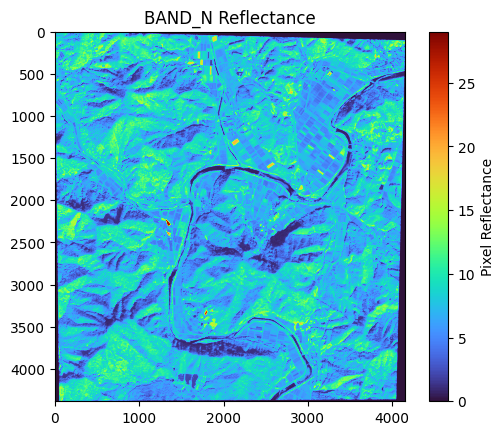

In [9]:
for _band_name in band_lst:

       _bands_reflectance = bands_info[_band_name]['REFLECTANCE']

       print(f"{_band_name} REFLECTANCE_INFO")
       # 기본 통계 정보 출력
       print(f"📌 최소값: {_bands_reflectance.min()}, 최대값: {_bands_reflectance.max()}, 평균값: {_bands_reflectance.mean()}")


       # 이미지 시각화
       plt.imshow(_bands_reflectance, cmap="turbo")
       plt.colorbar(label="Pixel Reflectance")
       plt.title(f"{_band_name} Reflectance")
       plt.show()

In [13]:
bands_info['BAND_C']['REFLECTANCE']

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.77784444, 0.63935582, 0.62089067, ..., 0.        , 0.        ,
        0.        ],
       [0.72014085, 0.68782683, 0.68321055, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

## 식생지수 계산

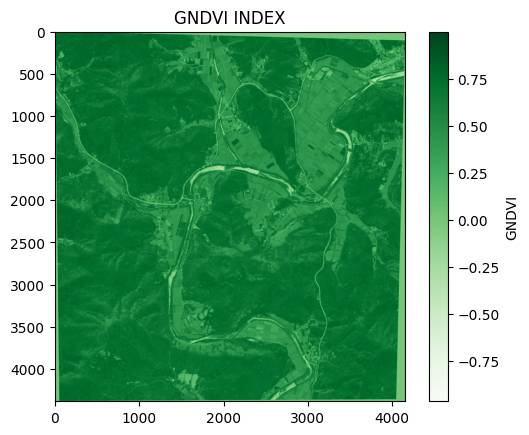

In [18]:
## GNDVI
# (NIR - GREEN) / (NIR + GREEN)

nir_band = bands_info['BAND_N']['REFLECTANCE']
green_band = bands_info['BAND_G']['REFLECTANCE']

gndvi_index = (nir_band - green_band) / (nir_band + green_band + 1e-6) ## 0으로 나누는 오류 방지

plt.imshow(gndvi_index, cmap="Greens")
plt.colorbar(label="GNDVI")
plt.title(f"GNDVI INDEX")
plt.show()

## TIF 파일 저장
green_meta = meta.copy()
green_meta.update(count=1, dtype=rasterio.float32)

with rasterio.open('GNDVI.tif', "w", **green_meta) as dst:
    dst.write(gndvi_index.astype(rasterio.float32), 1)

### 팬샤프닝 적용